### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [0]:
import tensorflow as tf
tf.set_random_seed(42)

In [2]:
tf.__version__

'1.14.0'

### Collect Data

In [3]:
import keras

Using TensorFlow backend.


In [0]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [5]:
print(testY[0:5])

[9 2 1 1 6]


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [0]:
train_Y = tf.keras.utils.to_categorical(trainY, num_classes = 10)
test_Y = tf.keras.utils.to_categorical(testY, num_classes = 10)

In [7]:
print(train_Y.shape)
print('First 5 examples now are: ', train_Y[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [0]:
train_X = trainX.astype('float32') / 255
test_X = testX.astype('float32') / 255

### Visualize the data

Plot first 10 images in the triaining set and their labels.

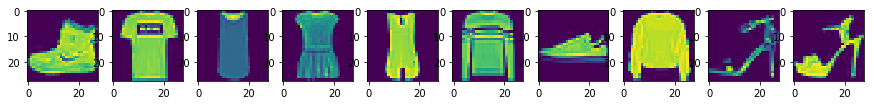

label for each of the above image:
[9 0 0 3 0 2 7 2 5 5]


In [9]:
import matplotlib.pyplot as plt
def show_images(X, locs):
    if isinstance(locs, int):
        locs = [locs]
    fig=plt.figure(figsize=(15, 10))
    for i, val in enumerate(locs):
        fig.add_subplot(1, len(locs), i+1)
        plt.imshow(X[val].reshape((28, 28)))
    plt.show()
    
show_images(trainX,[0,1,2,3,4,5,6,7,8,9])
print("label for each of the above image:")
print(trainY[0:10])

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [10]:
model_1 = keras.Sequential([keras.layers.Flatten(input_shape=(28, 28)),
                          keras.layers.Dense(10, activation=tf.nn.softmax)])
model_1.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

W0728 08:40:12.322597 139814125664128 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0728 08:40:12.328603 139814125664128 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0728 08:40:12.509080 139814125664128 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0728 08:40:12.525016 139814125664128 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0728 08:40:12.547158 139814125664128 deprecation_wrappe

### Execute the model using model.fit()

In [11]:
model_1.fit(train_X, train_Y, epochs=50, validation_split=0.25)

W0728 08:40:18.617206 139814125664128 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0728 08:40:18.668591 139814125664128 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:986: The name tf.assign_add is deprecated. Please use tf.compat.v1.assign_add instead.



Train on 45000 samples, validate on 15000 samples
Epoch 1/50
45000/45000 [==============================] - 2s 48us/step - loss: 0.8857 - acc: 0.7225 - val_loss: 0.6669 - val_acc: 0.7872
Epoch 2/50
45000/45000 [==============================] - 2s 42us/step - loss: 0.6233 - acc: 0.7982 - val_loss: 0.5943 - val_acc: 0.8043
Epoch 3/50
45000/45000 [==============================] - 2s 43us/step - loss: 0.5671 - acc: 0.8147 - val_loss: 0.5553 - val_acc: 0.8161
Epoch 4/50
45000/45000 [==============================] - 2s 43us/step - loss: 0.5372 - acc: 0.8229 - val_loss: 0.5293 - val_acc: 0.8221
Epoch 5/50
45000/45000 [==============================] - 2s 43us/step - loss: 0.5169 - acc: 0.8292 - val_loss: 0.5125 - val_acc: 0.8264
Epoch 6/50
45000/45000 [==============================] - 2s 43us/step - loss: 0.5030 - acc: 0.8319 - val_loss: 0.5028 - val_acc: 0.8280
Epoch 7/50
45000/45000 [==============================] - 2s 43us/step - loss: 0.4915 - acc: 0.8364 - val_loss: 0.4967 - val_acc

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [0]:
# import BatchNormalization
from keras.layers.normalization import BatchNormalization
model_2 = keras.Sequential([keras.layers.Flatten(input_shape=(28, 28)),
                          keras.layers.BatchNormalization(),
                          keras.layers.Dense(10, activation=tf.nn.softmax)])
model_2.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Execute the model

In [13]:
model_2.fit(train_X, train_Y, epochs=50, validation_split=0.25)

Train on 45000 samples, validate on 15000 samples
Epoch 1/50
45000/45000 [==============================] - 3s 67us/step - loss: 0.6111 - acc: 0.7886 - val_loss: 0.5106 - val_acc: 0.8181
Epoch 2/50
45000/45000 [==============================] - 3s 61us/step - loss: 0.4955 - acc: 0.8302 - val_loss: 0.4639 - val_acc: 0.8387
Epoch 3/50
45000/45000 [==============================] - 3s 61us/step - loss: 0.4748 - acc: 0.8353 - val_loss: 0.4602 - val_acc: 0.8380
Epoch 4/50
45000/45000 [==============================] - 3s 61us/step - loss: 0.4600 - acc: 0.8398 - val_loss: 0.4478 - val_acc: 0.8436
Epoch 5/50
45000/45000 [==============================] - 3s 61us/step - loss: 0.4501 - acc: 0.8445 - val_loss: 0.4431 - val_acc: 0.8480
Epoch 6/50
45000/45000 [==============================] - 3s 62us/step - loss: 0.4468 - acc: 0.8445 - val_loss: 0.4408 - val_acc: 0.8485
Epoch 7/50
45000/45000 [==============================] - 3s 61us/step - loss: 0.4398 - acc: 0.8467 - val_loss: 0.4341 - val_acc

### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [0]:
from keras.optimizers import SGD
sgd = SGD(lr=0.001)
model_3 = keras.Sequential([keras.layers.Flatten(input_shape=(28, 28)),
                          keras.layers.BatchNormalization(),
                          keras.layers.Dense(10, activation=tf.nn.softmax)])
model_3.compile(optimizer=sgd,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
model_3.fit(train_X, train_Y, epochs=50, validation_split=0.25)

Train on 45000 samples, validate on 15000 samples
Epoch 1/50
45000/45000 [==============================] - 3s 73us/step - loss: 1.0246 - acc: 0.6480 - val_loss: 0.7107 - val_acc: 0.7499
Epoch 2/50
45000/45000 [==============================] - 3s 62us/step - loss: 0.6773 - acc: 0.7685 - val_loss: 0.6096 - val_acc: 0.7889
Epoch 3/50
45000/45000 [==============================] - 3s 62us/step - loss: 0.6115 - acc: 0.7911 - val_loss: 0.5671 - val_acc: 0.8034
Epoch 4/50
45000/45000 [==============================] - 3s 62us/step - loss: 0.5763 - acc: 0.8042 - val_loss: 0.5415 - val_acc: 0.8119
Epoch 5/50
45000/45000 [==============================] - 3s 63us/step - loss: 0.5548 - acc: 0.8106 - val_loss: 0.5254 - val_acc: 0.8163
Epoch 6/50
45000/45000 [==============================] - 3s 68us/step - loss: 0.5417 - acc: 0.8156 - val_loss: 0.5140 - val_acc: 0.8219
Epoch 7/50
45000/45000 [==============================] - 3s 67us/step - loss: 0.5289 - acc: 0.8198 - val_loss: 0.5048 - val_acc

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [0]:
model_4 = keras.Sequential([keras.layers.Flatten(input_shape=(28, 28)),
                          keras.layers.Dense(100, activation=tf.nn.sigmoid),
                          keras.layers.Dense(100, activation=tf.nn.sigmoid),
                          keras.layers.Dense(10, activation=tf.nn.softmax)])
sgd = SGD(lr=0.03)
model_4.compile(optimizer=sgd,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
model_4.fit(train_X, train_Y, epochs=50, validation_split=0.25)

Train on 45000 samples, validate on 15000 samples
Epoch 1/50
45000/45000 [==============================] - 3s 77us/step - loss: 1.6919 - acc: 0.4725 - val_loss: 1.1143 - val_acc: 0.6680
Epoch 2/50
45000/45000 [==============================] - 3s 71us/step - loss: 0.9097 - acc: 0.7017 - val_loss: 0.7694 - val_acc: 0.7118
Epoch 3/50
45000/45000 [==============================] - 3s 71us/step - loss: 0.6991 - acc: 0.7499 - val_loss: 0.6447 - val_acc: 0.7673
Epoch 4/50
45000/45000 [==============================] - 3s 72us/step - loss: 0.6122 - acc: 0.7738 - val_loss: 0.5831 - val_acc: 0.7872
Epoch 5/50
45000/45000 [==============================] - 3s 71us/step - loss: 0.5618 - acc: 0.7968 - val_loss: 0.5472 - val_acc: 0.8051
Epoch 6/50
45000/45000 [==============================] - 3s 71us/step - loss: 0.5264 - acc: 0.8122 - val_loss: 0.5144 - val_acc: 0.8120
Epoch 7/50
45000/45000 [==============================] - 3s 71us/step - loss: 0.5000 - acc: 0.8238 - val_loss: 0.5034 - val_acc

## Review model

In [20]:
test_loss, test_acc = model_1.evaluate(test_X, test_Y)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 0s 21us/step
Test accuracy: 0.8416


In [21]:
test_loss, test_acc = model_2.evaluate(test_X, test_Y)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 0s 34us/step
Test accuracy: 0.8425


In [22]:
test_loss, test_acc = model_3.evaluate(test_X, test_Y)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 0s 33us/step
Test accuracy: 0.8389


In [0]:
test_loss, test_acc = model_4.evaluate(test_X, test_Y)

print('Test accuracy:', test_acc)

10000/10000 [==============================] - 0s 27us/step
Test accuracy: 0.8679


### Run the model

In [0]:
predictions = model_4.predict(test_X)

In [28]:
np.argmax(predictions[0])

9

In [30]:
testY[0]

9